In [9]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from catboost import cv, Pool
from sklearn import metrics


In [10]:
train = pd.read_csv("../artifacts/feature_engineering/features_train.csv")
test = pd.read_csv("../artifacts/feature_engineering/features_test.csv")

target = "log_price"

X_train = train.drop(columns=target)
y_train = train[target]

X_test = test.drop(columns=target)
y_test = test[target]


In [11]:
model = CatBoostRegressor(random_seed=2026)
model = model.fit(X_train, y_train, logging_level="Silent")

In [12]:
def get_cv_score(X, y, params):
    cv_params = params.copy()
    cv_params["eval_metric"] = "RMSE"

    cv_dataset = Pool(data=X, label=y)

    cv_results = cv(
        params=cv_params,
        pool=cv_dataset,
        fold_count=5,
        shuffle=True,
        partition_random_seed=42,
        verbose=False,
    )

    target_col = [col for col in cv_results.columns if "test-R2-mean" in col]

    if not target_col:
        target_col = [
            col for col in cv_results.columns if "test-" in col and "-mean" in col
        ]
        print(f"R2 not found. Available metrics: {cv_results.columns.tolist()}")

    final_score = cv_results[target_col[0]].iloc[-1]

    return (
        round(final_score * 100, 2) if "R2" in target_col[0] else round(final_score, 4)
    )

In [13]:
def compute_catboost_metrics(model, x_test, y_test, x_train_full, y_train_full):
    preds = model.predict(x_test)
    r2 = metrics.r2_score(y_test, preds)

    params = model.get_params()
    cv_score = get_cv_score(x_train_full, y_train_full, params)

    return pd.DataFrame(
        [
            {
                "R2": round(r2, 3),
                "mse": round(metrics.mean_squared_error(y_test, preds), 3),
                "rmse": round(np.sqrt(metrics.mean_squared_error(y_test, preds)), 3),
                "mae": round(metrics.mean_absolute_error(y_test, preds), 3),
                "cv_score": cv_score,
            }
        ]
    )

In [14]:
val_metrics = compute_catboost_metrics(model, X_test, y_test, X_train, y_train)
val_metrics


Training on fold [0/5]

bestTest = 0.4569993138
bestIteration = 893

Training on fold [1/5]

bestTest = 0.4507777105
bestIteration = 970

Training on fold [2/5]

bestTest = 0.4615408347
bestIteration = 999

Training on fold [3/5]

bestTest = 0.4509432644
bestIteration = 999

Training on fold [4/5]

bestTest = 0.4615486177
bestIteration = 999

R2 not found. Available metrics: ['iterations', 'test-RMSE-mean', 'test-RMSE-std', 'train-RMSE-mean', 'train-RMSE-std']


,R2,mse,rmse,mae,cv_score
0,0.851,0.213,0.462,0.342,0.4564


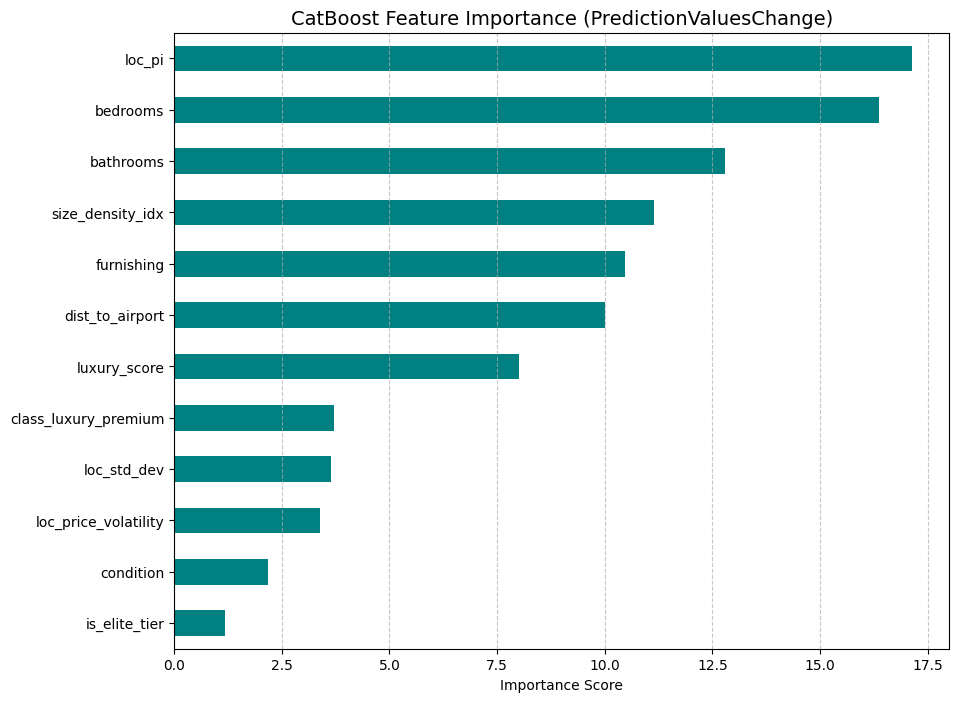

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

feat_importances = pd.Series(
    model.get_feature_importance(), index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feat_importances.tail(20).plot(kind="barh", color="teal")
plt.title("CatBoost Feature Importance (PredictionValuesChange)", fontsize=14)
plt.xlabel("Importance Score")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()


In [16]:
model.get_all_params()

{'nan_mode': 'Min',
 'eval_metric': 'RMSE',
 'iterations': 1000,
 'sampling_frequency': 'PerTree',
 'leaf_estimation_method': 'Newton',
 'random_score_type': 'NormalWithModelSizeDecrease',
 'grow_policy': 'SymmetricTree',
 'penalties_coefficient': 1,
 'boosting_type': 'Plain',
 'model_shrink_mode': 'Constant',
 'feature_border_type': 'GreedyLogSum',
 'bayesian_matrix_reg': 0.10000000149011612,
 'eval_fraction': 0,
 'force_unit_auto_pair_weights': False,
 'l2_leaf_reg': 3,
 'random_strength': 1,
 'rsm': 1,
 'boost_from_average': True,
 'model_size_reg': 0.5,
 'pool_metainfo_options': {'tags': {}},
 'subsample': 0.800000011920929,
 'use_best_model': False,
 'random_seed': 2026,
 'depth': 6,
 'posterior_sampling': False,
 'border_count': 254,
 'classes_count': 0,
 'auto_class_weights': 'None',
 'sparse_features_conflict_fraction': 0,
 'leaf_estimation_backtracking': 'AnyImprovement',
 'best_model_min_trees': 1,
 'model_shrink_rate': 0,
 'min_data_in_leaf': 1,
 'loss_function': 'RMSE',
 'l